In [ ]:
%reload_ext tensorboard

In [ ]:
#rm -rf ./logs/

In [ ]:
%tensorboard --logdir logs/gradient_tape

In [1]:
import tensorflow as tf

In [2]:
path = '/Users/erinbjorkeli/Documents/GitHub/deep-spectra/Autoencode_classifier_2022-07-04 15:50:27.460220'
model = tf.keras.models.load_model(path)

2022-07-06 03:41:58.683112: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-07-06 03:41:58.683206: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Metal device set to: Apple M1


In [ ]:
model.summary()

In [3]:
import numpy as np
import os

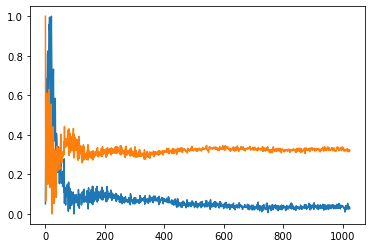

In [274]:
i = 2370  # norm 14000  #gbm 330
path = '/Users/erinbjorkeli/phd/Data_Spectra /ReIm_data_3/gbm'
labtest = np.load(os.path.join(path, 'train/train_time_data.npy'), allow_pickle=True)[i] # nhx 100, 220
plt.plot(labtest)

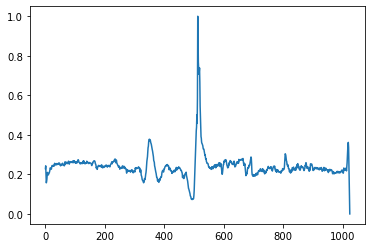

In [275]:
labtest2 = np.load(os.path.join(path, 'train/train_freq_data.npy'), allow_pickle=True)[i]
plt.plot(labtest2[:])

/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


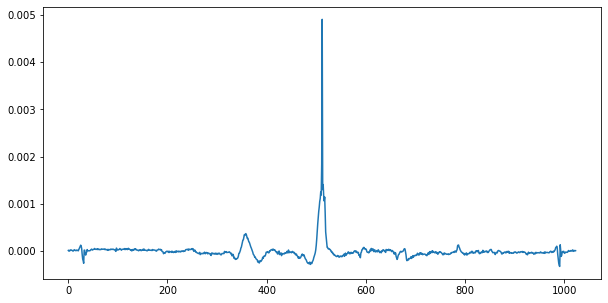

In [276]:
ii = fft_spectra(labtest[np.newaxis])

In [297]:
labtest.shape

(1024, 2)

In [307]:
test = None
np.concatenate((test,labtest)).shape

ValueError: zero-dimensional arrays cannot be concatenated

In [277]:
_, _, _, x1, _ = model.predict(labtest[np.newaxis])

1/1 [==============================] - 0s 44ms/step


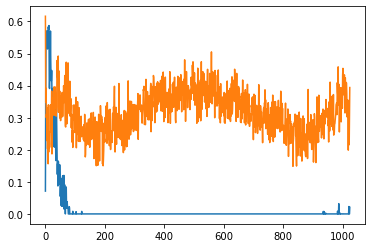

In [278]:
plt.plot(x1[0])

/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


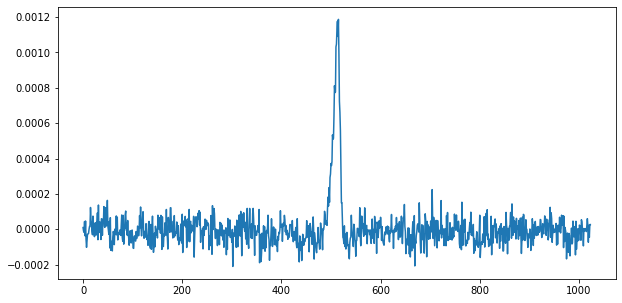

In [279]:
jj = fft_spectra(x1)

In [280]:
cf = 128#*2 #* 1e6
dwelltime = 400#833
bandwidth = 1 / dwelltime
points = 1024
x = np.linspace(-bandwidth / 2, bandwidth / 2, points)
xs = hz2ppm(cf, x, shift=True, shift_amount=4.65)

/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


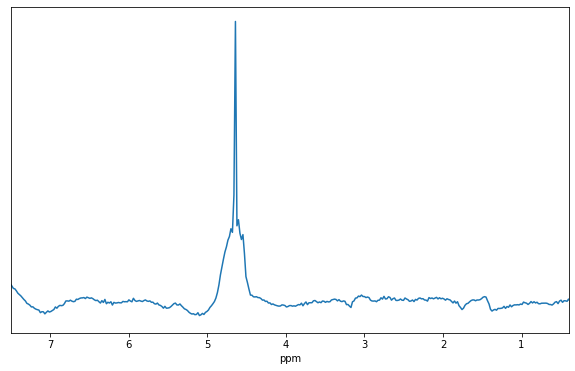

In [281]:
fig = plt.figure(figsize=(10,6))
plt.plot(np.flip(xs), ii)
plt.yticks([])
plt.xlim([0.4, 7.5])
plt.xlabel('ppm')
plt.gca().invert_xaxis()
#plt.plot(jj)

/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


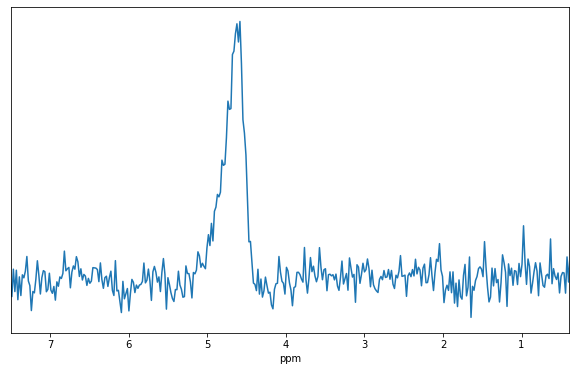

In [282]:
fig = plt.figure(figsize=(10,6))
plt.plot(np.flip(xs), jj)
plt.yticks([])
plt.xlim([0.4, 7.5])
plt.xlabel('ppm')
plt.gca().invert_xaxis()
#plt.plot(jj)

In [ ]:
matplotlib.rcParams.update({'font.size': 10})


In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
aa = np.load('test_reconstruction_dense_10eps_1e3.npy')
bb = np.load('input_reconstruction_dense_1e3.npy')
plt.plot(aa[0,:,1])
plt.plot(bb[0,:,1])

In [5]:
from Utils.Domain_transform import fft_spectra

In [ ]:
aa.shape

In [ ]:
fft_spectra(aa)

In [ ]:
from Utils.spectra_error_plotting import Visualise

In [ ]:
a, b = fft_spectra(aa, plot=False), fft_spectra(bb, plot=False)

In [15]:
def hz2ppm(cf, hz, shift=True, shift_amount=0):
    """Convert frequency scale to frequency scale with optional shift."""
    if shift:
        return 1e6 * hz / cf + shift_amount
    else:
        return 1e6 * hz / cf

In [ ]:
cf = 128 #* 1e6
dwelltime = 833
bandwidth = 1 / dwelltime
points = 1024
x = np.linspace(-bandwidth / 2, bandwidth / 2, points)
xs = hz2ppm(cf, x, shift=True, shift_amount=4.65)

In [ ]:
fig = plt.figure(figsize=(10,6))
plt.plot(xs, a)#[550:800])
plt.plot(xs, b)#[550:800])
plt.yticks([])
plt.xlim([0.4, 4.2])
plt.xlabel('ppm')
plt.gca().invert_xaxis()

In [ ]:
x = np.arange(10)
x

In [ ]:
np.random.shuffle(x)
x

In [ ]:
vis = Visualise(b, a, 0)

In [ ]:
vis.error(N=1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import *

In [ ]:
a = np.load('test_reconstruction_lat128_1e5_f3.npy')
b = np.load('input_reconstruction_lat128_1e5_f3.npy')
print(a.shape, b.shape)

In [ ]:
plt.plot(a[0,:,])

In [ ]:
plt.plot(a[0,:,])

In [ ]:
plt.plot(b[0,:,])

In [ ]:
aa = np.load('test_reconstruction.npy')
bb = np.load('input_reconstruction.npy')
plt.plot(aa[0,:,])
#plt.plot(bb[0,:,])

In [ ]:
# Histograms for prediction

a = # load predictions of whole scan
threshold = 0.5
a1 = a[np.where(a <= threshold)]
a2 = a[np.where(a > threshold)]

plt.hist(a1)
plt.hist(a2)

In [ ]:
z = np.arange(50)

In [ ]:
zz = 1 / ((1 + z) ** 0.0)

In [ ]:
plt.plot(zz)

In [ ]:
from tensorflow.keras import layers, models

timesteps = 2  # Length of your sequences
input_dim = 1024 
latent_dim = 256

inputs = layers.Input(shape=(timesteps, input_dim))
x = layers.LSTM(512, return_sequences=True)(inputs)
encoded = layers.LSTM(latent_dim)(x)

decoded = layers.RepeatVector(timesteps)(encoded)
x = layers.LSTM(512, return_sequences=True)(decoded)
decoded = layers.LSTM(input_dim, return_sequences=True)(x)

sequence_autoencoder = models.Model(inputs, decoded)
encoder = models.Model(inputs, encoded)

In [ ]:
z = sequence_autoencoder(bb.transpose([0,2,1]))

In [ ]:
z.shape

In [ ]:
q = encoder(bb)

In [ ]:
q.shape

In [ ]:
plt.plot(z.numpy().transpose([0,2,1])[0])

In [ ]:
bb = bb.transpose([0,2,1])

In [ ]:
bb.shape

In [ ]:
import tensorflow as tf

In [ ]:
sequence_autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='mean_squared_error')

In [ ]:
sequence_autoencoder.fit(bb, bb, epochs=100)

In [ ]:
zz = sequence_autoencoder.predict(bb)

In [ ]:
zz.shape

In [ ]:
plt.plot(zz.transpose([0,2,1])[0])

In [ ]:
plt.plot(bb.transpose([0,2,1])[0])

In [ ]:
def lstm_shapify(sequence, look_back, features):
    res = np.empty((look_back, len(sequence), features), dtype=np.float32)

    for i in range(look_back):
        res[i] = np.roll(sequence, -i * features)

    return np.transpose(res, axes=(1, 0, 2))[:-look_back + 1]


def make_dataset(x_flights, look_back, features):
    x = np.empty((0, look_back, features), dtype=np.float32)

    for i in range(len(x_flights)):
        x_sample = x_flights[i]

        x = np.concatenate([x, lstm_shapify(x_sample, look_back, features)])
    return x

bbb = make_dataset(bb, 7, 2)

In [ ]:
bbb.shape

In [ ]:
from Utils.get_args import get_args
from Utils.get_config import get_config

config = get_config('configs/config_test_dense.txt')

In [ ]:
from Models.Autoencoder_dense import *

In [ ]:
bb = bb.transpose([0,2,1])

In [ ]:
dim = [1024, 2]
model = autoencodeclass(dim, config)

In [ ]:
filters = config['filters']
latent_dim = 256 #config['latent_dim']
norm = True
activation = 'elu'
input_shape = [1024, 2]

input = Input((input_shape))

# Autoencoder
x = Flatten()(input)
#x = input
# Hidden layers:
for f in filters:
    x = Dense(f, activation=activation)(x)
    #if norm:
    #    x = BatchNormalization()(x, training=True)
    #if activation is not None:
    #    x = Activation(activation)(x)
#x = Dense(1024, activation='elu')(x)
x = Flatten()(x)
encoded = Dense(latent_dim, activation='relu')(x)

x = encoded
for f in reversed(filters):
    x = Dense(f, activation=activation)(x)
    #if norm:
    #    x = BatchNormalization()(x, training=True)
    #if activation is not None:
    #    x = Activation(activation)(x)
#x = Dense(1024, activation='elu')(x)
x = Dense(2*1024, 'relu')(x)
#x = Activation(activation)(x)
out0 = Reshape((1024, 2))(x)

encoder = Model(input, encoded)
autoencoder = Model(input, out0)

autoencoder.summary()

In [ ]:
encoder(bb)

In [ ]:
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='mean_squared_error')

In [ ]:
autoencoder.fit(bb, bb, epochs=100)

In [ ]:
z1 = autoencoder.predict(bb)
plt.plot(z1[0])

In [ ]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [ ]:
timesteps = 1024  # Length of your sequences
input_dim = 2 
latent_dim = 256

filters = [512,latent_dim]

inputs = Input(shape=(timesteps, input_dim))
x = Permute((2,1))(inputs)

for f in filters[:-1]:
    x = LSTM(f, return_sequences=True)(x)
#x = LSTM(filters[0], return_sequences=True)(x)
    
encoded = LSTM(filters[-1], return_sequences=False)(x) # encoded
x = RepeatVector(2)(encoded)

for f in reversed(filters):
    x = LSTM(f, return_sequences=True)(x)
#x = LSTM(filters[1], return_sequences=True)(x)
#x = LSTM(filters[0], return_sequences=True)(x)

#x = LSTM(timesteps, return_sequences=True)(x)
x = TimeDistributed(Dense(1024))(x)
decoded = Permute((2,1))(x)


encoder = Model(inputs, encoded)
autoencoder = Model(inputs, decoded)

autoencoder.summary()

In [ ]:
z0 = autoencoder(bb)

In [ ]:
plt.plot(z0[0])

In [ ]:
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mean_squared_error')

In [ ]:
autoencoder.fit(bb, bb, epochs=10)

In [ ]:
z1 = autoencoder.predict(bb)

In [ ]:
plt.plot(z1[0])

In [ ]:
z2 = encoder(z1)

In [308]:
# 109 for example
tn = 11169
fp = 79
tp = 8683
fn = 7740

cm = [[tn, fp], [tp,fn]]

labels = ['healthy', 'gbm']

In [310]:
(tp + tn) / (tp+tn+fp+fn)

0.7174298001517835

In [ ]:
c1 = [5953,0,1166,0]
c2 = [524,0,571,0]
c3 = [5676,0,4477,0]
c4 = [1951,0,7353,0]

cm = [c1,c2,c3,c4]

labels = ['m1', 'm2', 'm3', 'm4']

In [ ]:
c1 = [5928,0,0,0,0,1191]
c2 = [2704,0,0,0,0,6600]
c3 = [151,0,0,0,0,215]
c4 = [173,0,0,0,0,196]
c5 = [177,0,0,0,0,183]
c6 = [6394,0,0,0,0,3759]

cm = [c1,c2,c3,c4,c5,c6]

labels = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6']

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt   
import matplotlib
from matplotlib.colors import LogNorm, Normalize


matplotlib.rcParams.update({'font.size': 22})

fig = plt.subplots(1,1,figsize=(12,10))
ax = plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax, cmap=sns.color_palette("PuBu", as_cmap=True))#, norm=LogNorm());  #annot=True to annotate cells, ftm='g' to disable scientific notation


# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(labels); ax.yaxis.set_ticklabels(labels);


In [ ]:
# create cms

# example of recreated spectra...